In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# First We will Load the data

In [79]:
df = pd.read_csv("students.csv")


# Task 1 — Data Exploration with Pandas

# 1) We print 1st 5 rows

In [80]:
print("First 5 rows of dataset:\n")
print(df.head())

First 5 rows of dataset:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


# 2. We print the shape and data types

In [81]:
print("\nDataset shape (rows, columns):")
print(df.shape)

print("\nData types of each column:")
print(df.dtypes)


Dataset shape (rows, columns):
(15, 9)

Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


# 3) We print summary statistics for all numerical columns

In [82]:
print("\nSummary statistics for numeric columns:")
print(df.describe())


Summary statistics for numeric columns:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000 

# 4. We print the count of stundents passed & failed

In [83]:
print("\nCount of students who passed and failed:")
print(df['passed'].value_counts())


Count of students who passed and failed:
passed
1    9
0    6
Name: count, dtype: int64


# 5) We print the average score per subject 


In [84]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# For passing students
print("\nAverage subject scores for PASSING students:")
print(df[df['passed'] == 1][subject_cols].mean())


Average subject scores for PASSING students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64


### For passing students


In [85]:
print("\nAverage subject scores for PASSING students:")
print(df[df['passed'] == 1][subject_cols].mean())


Average subject scores for PASSING students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64


### For failing students

In [86]:
print("\nAverage subject scores for FAILING students:")
print(df[df['passed'] == 0][subject_cols].mean())


Average subject scores for FAILING students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


# 6. Student with highest overall average
### We calculate overall average across 5 subjects

In [87]:
df['average_score'] = df[subject_cols].mean(axis=1)

### We Find the student with highest average

In [88]:
top_student = df.loc[df['average_score'].idxmax()]

In [89]:
print("\nStudent with highest overall average:")
print(top_student[['name', 'average_score']])


Student with highest overall average:
name             Diana
average_score     94.0
Name: 3, dtype: object


# Task 2 — Data Visualization with Matplotlib

### Now we are adding a new column - avg_score column


In [90]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Creating Bar Chart showing — Average score per subject

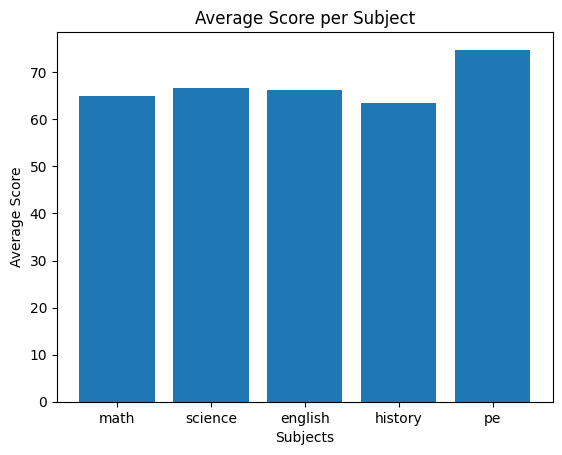

In [91]:
# We need to calculate mean score per subject

subject_means = df[subject_cols].mean()

# We create Bar Chart

plt.figure()
plt.bar(subject_cols, subject_means)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("Task2.1Bar Chart.png")
plt.show()

# 2 We create Histogram showing — Math score distribution


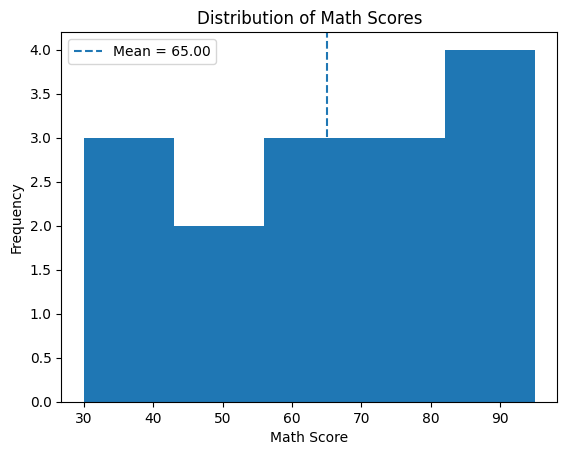

In [92]:

plt.figure()

plt.hist(df['math'], bins=5)

# We add a mean line

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("Task2.2Histogram.png")
plt.show()


# 3. We create a Scatter Plot showing — Study hours per day vs Average Score

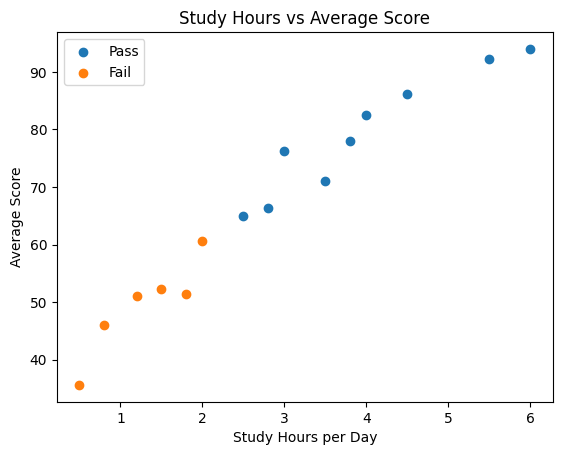

In [93]:

plt.figure()

# Separating pass and fail students

pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

# We Plot separately 

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label="Pass")
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("Task2.3Scatter Plot.png")
plt.show()


# 4. We create a Box Plot showing — Attendance (Pass vs Fail)


C:\Users\Dell\AppData\Local\Temp\ipykernel_26284\3516609060.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


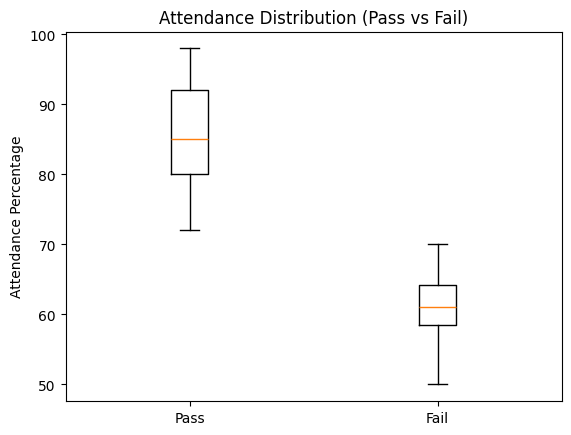

In [94]:
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance Percentage")

plt.savefig("Task2.4Box Plot.png")
plt.show()

# 5. We create a Line Plot showing — Maths vs Science scores


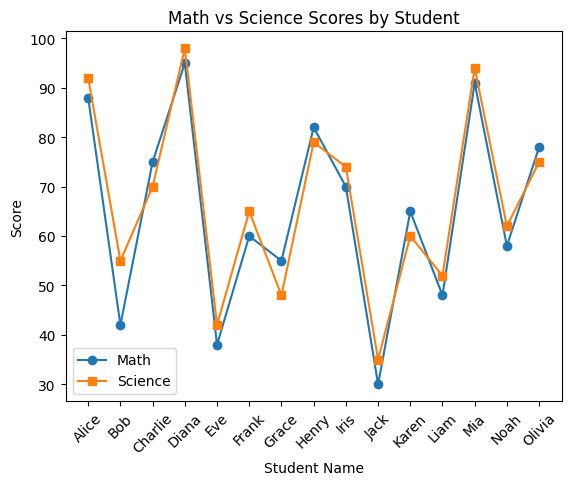

In [95]:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

# To avoid Over laping

plt.xticks(rotation=45) 
plt.legend()

plt.savefig("Task2.5Line Plot.png")
plt.show()

# Task 3 — Data Visualization with Seaborn

### We need to Create one avg_score column - it is needed for scatter plot

In [96]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. We create a Bar plot ( with Math & Science split by Pass/Fail)


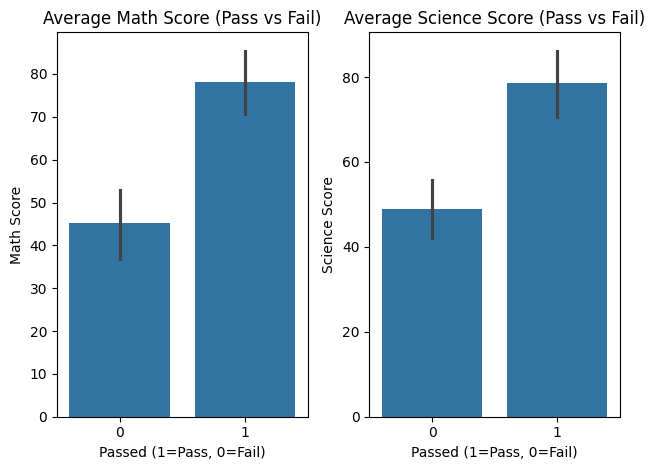

In [97]:
plt.figure()

# A seperate Subplot 1 → Math

ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (1=Pass, 0=Fail)")
ax1.set_ylabel("Math Score")

# A seperate Subplot 2 → Science

ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (1=Pass, 0=Fail)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("Task3.1_seaborn_barchart.png")
plt.show()

# 2. We create a Scatter plot with regression lines


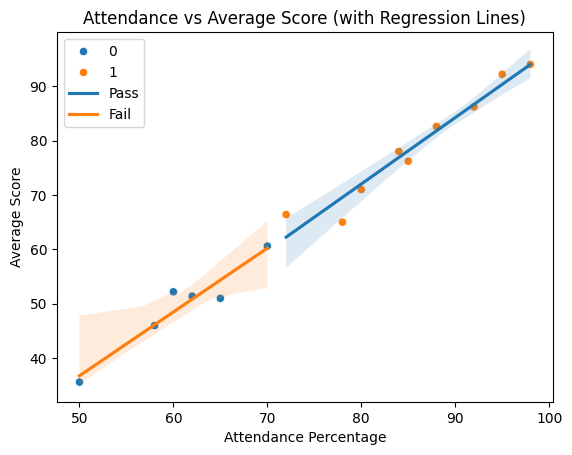

In [98]:

plt.figure()

# A Scatter plot (colored by pass/fail)

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for PASS students

sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# A Regression line for FAIL students

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (with Regression Lines)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("Task3.2_seaborn_ScatterPlot.png")
plt.show()

## Seaborn vs Matplotlib

# In this task, I felt Seaborn easier for quick visualizations, especially for averages and trends.
# It requires less code compared to Matplotlib which provides more control
# when customizing plots in detail.

## Task 4 - Machine Learning with Sciket Learn

Matplotlib is building the font cache; this may take a moment.



Training Accuracy: 1.00
Test Accuracy: 1.00

Test Predictions:

Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct

Feature Importance:
english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


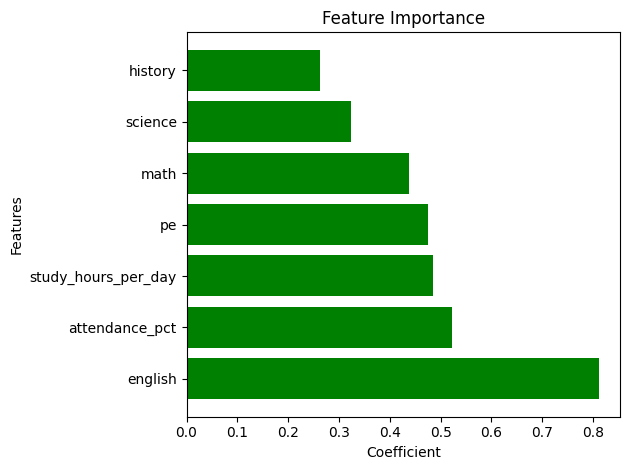


New Student Prediction:
Predicted: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


/Users/shubigoswami/Documents/Assignment/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def main():
    # -------------------------------
    # Load dataset (your requirement)
    # -------------------------------
    df = pd.read_csv("students.csv")

    # -------------------------------
    # Step 1 — Prepare Data
    # -------------------------------
    feature_cols = [
        'math', 'science', 'english',
        'history', 'pe',
        'attendance_pct',
        'study_hours_per_day'
    ]

    X = df[feature_cols]
    y = df['passed']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -------------------------------
    # Step 2 — Train Model
    # -------------------------------
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    print(f"\nTraining Accuracy: {model.score(X_train_scaled, y_train):.2f}")

    # -------------------------------
    # Step 3 — Evaluate Model
    # -------------------------------
    y_pred = model.predict(X_test_scaled)

    print(f"Test Accuracy: {model.score(X_test_scaled, y_test):.2f}\n")

    print("Test Predictions:\n")
    for i, idx in enumerate(X_test.index):
        name = df.loc[idx, 'name']
        actual = y_test.iloc[i]
        predicted = y_pred[i]

        result = "✅ Correct" if actual == predicted else "❌ Wrong"
        print(f"{name} → Actual: {actual}, Predicted: {predicted} → {result}")

    # -------------------------------
    # Step 4 — Feature Importance
    # -------------------------------
    coefficients = model.coef_[0]
    feature_importance = list(zip(feature_cols, coefficients))

    feature_importance_sorted = sorted(
        feature_importance,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    print("\nFeature Importance:")
    for feature, coef in feature_importance_sorted:
        print(f"{feature}: {coef:.3f}")

    # Plot
    features = [f[0] for f in feature_importance_sorted]
    values = [f[1] for f in feature_importance_sorted]
    colors = ['green' if v > 0 else 'red' for v in values]

    plt.figure()
    plt.barh(features, values, color=colors)
    plt.title("Feature Importance")
    plt.xlabel("Coefficient")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()

    # -------------------------------
    # Step 5 — New Student Prediction
    # -------------------------------
    new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

    new_student_scaled = scaler.transform(new_student)

    prediction = model.predict(new_student_scaled)[0]
    probability = model.predict_proba(new_student_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"

    print("\nNew Student Prediction:")
    print(f"Predicted: {result}")
    print(f"Probability (Fail, Pass): {probability}")


if __name__ == "__main__":
    main()